# Notebook 2 — Regressão

**Aluno:** Pedro Pereira Dutra — RA: 24101026

---

## 1. Definição do Problema

**Problema:** Prever o valor mediano dos imóveis em blocos residenciais da Califórnia com base em características socioeconômicas e geográficas.

**Dataset:** California Housing Dataset — `sklearn.datasets.fetch_california_housing`
Dados extraídos do censo da Califórnia de 1990. Contém **20.640 registros**, cada um representando um bloco residencial, com **8 features** numéricas e 1 variável-alvo.

**Tipo de problema:** Regressão supervisionada — a variável-alvo é contínua (valor em USD).

**Variável-alvo:** `MedHouseVal` — valor mediano dos imóveis no bloco residencial, expresso em USD × 100k (ex: 2.5 = USD 250.000).

**Objetivo:** Construir, avaliar e otimizar um modelo de regressão capaz de prever `MedHouseVal` com base nas 8 features do bloco, aplicando múltiplos algoritmos, métricas de avaliação (MAE, MSE, RMSE, R²) e três técnicas de otimização de hiperparâmetros: Randomized Search, Bayesian Search e Grid Search.

In [ ]:
import pandas as pd
import numpy as npa
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('future.no_silent_downcasting', True) # para tirar os avisos do pandas

## Carregamento do Dataset:

In [ ]:
from sklearn.datasets import fetch_california_housing

# Carregando o dataset diretamente do sklearn — não requer download externo
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Informações gerais sobre o dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [ ]:
# Descrição estatística das variáveis numéricas
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
# Descrição das variáveis do dataset
descricao = {
    'MedInc':      'Renda mediana dos domicílios no bloco (dezenas de milhares de USD)',
    'HouseAge':    'Idade mediana dos imóveis no bloco (anos)',
    'AveRooms':    'Número médio de cômodos por domicílio',
    'AveBedrms':   'Número médio de quartos por domicílio',
    'Population':  'População total do bloco',
    'AveOccup':    'Número médio de moradores por domicílio',
    'Latitude':    'Latitude geográfica do bloco',
    'Longitude':   'Longitude geográfica do bloco',
    'MedHouseVal': '[ALVO] Valor mediano dos imóveis no bloco (USD x 100.000)'
}

for col, desc in descricao.items():
    print(f'  {col:<14}: {desc}')

  MedInc        : Renda mediana dos domicílios no bloco (dezenas de milhares de USD)
  HouseAge      : Idade mediana dos imóveis no bloco (anos)
  AveRooms      : Número médio de cômodos por domicílio
  AveBedrms     : Número médio de quartos por domicílio
  Population    : População total do bloco
  AveOccup      : Número médio de moradores por domicílio
  Latitude      : Latitude geográfica do bloco
  Longitude     : Longitude geográfica do bloco
  MedHouseVal   : [ALVO] Valor mediano dos imóveis no bloco (USD x 100.000)


### Interpretação — Carregamento do Dataset

O dataset foi carregado diretamente do `sklearn`, sem necessidade de download externo.

**Estrutura dos dados:**
- **Dimensões:** 20.640 linhas × 9 colunas (8 features preditoras + 1 variável-alvo)
- **Tipos:** todas as colunas são `float64` — sem variáveis categóricas, sem necessidade de encoding
- **Valores ausentes:** zero — dataset completamente preenchido, sem necessidade de imputação

**Descrição das features:**

| Feature | Descrição | Tipo |
|---|---|---|
| MedInc | Renda mediana do bloco (dezenas de milhares USD) | Numérica contínua |
| HouseAge | Idade mediana dos imóveis (anos) | Numérica contínua |
| AveRooms | Média de cômodos por domicílio | Numérica contínua |
| AveBedrms | Média de quartos por domicílio | Numérica contínua |
| Population | População total do bloco | Numérica contínua |
| AveOccup | Média de moradores por domicílio | Numérica contínua |
| Latitude | Latitude geográfica do bloco | Numérica contínua |
| Longitude | Longitude geográfica do bloco | Numérica contínua |
| **MedHouseVal** | **[ALVO] Valor mediano dos imóveis (USD × 100k)** | **Numérica contínua** |

As estatísticas descritivas (`df.describe()`) mostram médias, medianas e desvios padrão de cada variável, além de revelar a presença de outliers extremos em `AveOccup` (máx. 1.243), `AveRooms` (máx. 141) e `Population` (máx. 35.682), que serão analisados em detalhe na EDA.

## Análise Exploratória dos Dados:

In [ ]:
# Verificação de valores ausentes
print('Valores ausentes por coluna:')
print(df.isnull().sum())

Valores ausentes por coluna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### 1 - Distribuição da variável alvo

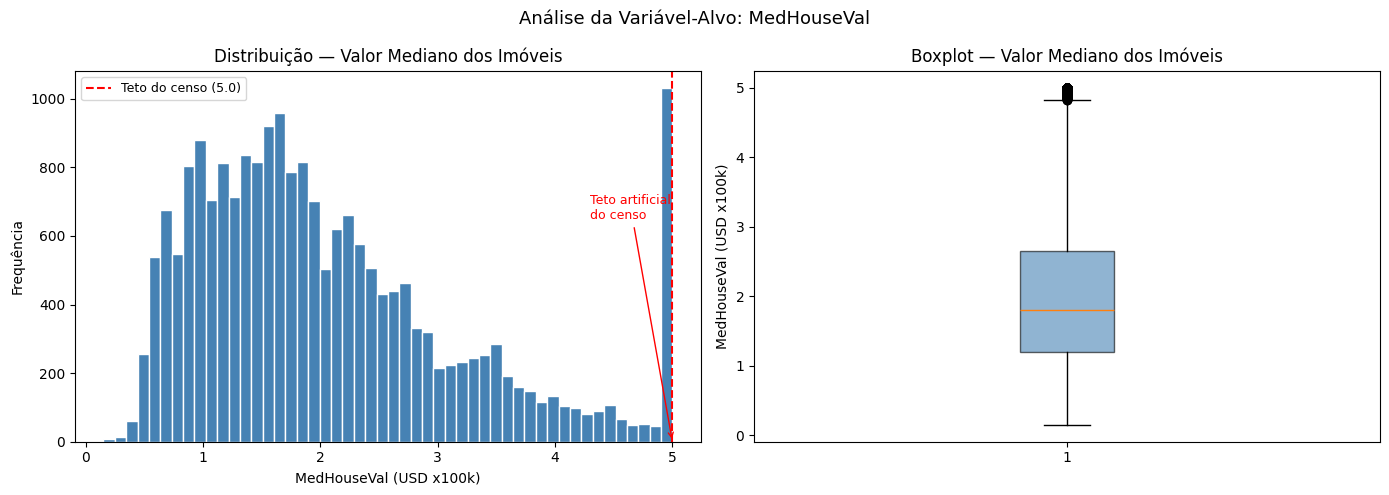

Média:          2.0686
Mediana:        1.7970
Desvio padrão:  1.1540
Mínimo:         0.1500
Máximo:         5.0000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma da variável alvo
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição — Valor Mediano dos Imóveis')
axes[0].set_xlabel('MedHouseVal (USD x100k)')
axes[0].set_ylabel('Frequência')
# Anotação explicando o pico artificial em 5.0 (truncamento do censo)
axes[0].axvline(x=5.0, color='red', linestyle='--', linewidth=1.5, label='Teto do censo (5.0)')
axes[0].annotate('Teto artificial\ndo censo', xy=(5.0, 0), xytext=(4.3, axes[0].get_ylim()[1]*0.6),
                 arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
axes[0].legend(fontsize=9)

# Boxplot da variável alvo
axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot — Valor Mediano dos Imóveis')
axes[1].set_ylabel('MedHouseVal (USD x100k)')

plt.suptitle('Análise da Variável-Alvo: MedHouseVal', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Média:          {df["MedHouseVal"].mean():.4f}')
print(f'Mediana:        {df["MedHouseVal"].median():.4f}')
print(f'Desvio padrão:  {df["MedHouseVal"].std():.4f}')
print(f'Mínimo:         {df["MedHouseVal"].min():.4f}')
print(f'Máximo:         {df["MedHouseVal"].max():.4f}')

### Interpretação — Distribuição da Variável Alvo

O histograma mostra que a variável alvo `MedHouseVal` apresenta assimetria positiva (cauda à direita), com a maioria dos blocos com valor entre USD 100k e USD 300k.

Estatísticas reais do dataset:
- Média: **2.07** (USD ~207k)
- Mediana: **1.80** (USD ~180k)
- Desvio padrão: **1.15**
- Mínimo: **0.15** (USD ~15k)
- Máximo: **5.00** (USD 500k)

A média ser maior que a mediana confirma a assimetria positiva. Há também um pico expressivo no valor máximo de 5.0 (USD 500k), que indica um **truncamento nos dados do censo** — imóveis acima desse valor foram todos registrados como 5.0. Esse comportamento impacta a capacidade do modelo de prever imóveis de alto valor, pois o modelo não consegue aprender a diferença entre imóveis que realmente valem exatamente USD 500k e os que valem mais.

O boxplot revela outliers superiores, confirmando blocos com valores acima da faixa típica.

### 2 - Distribuição de todas as variáveis numéricas

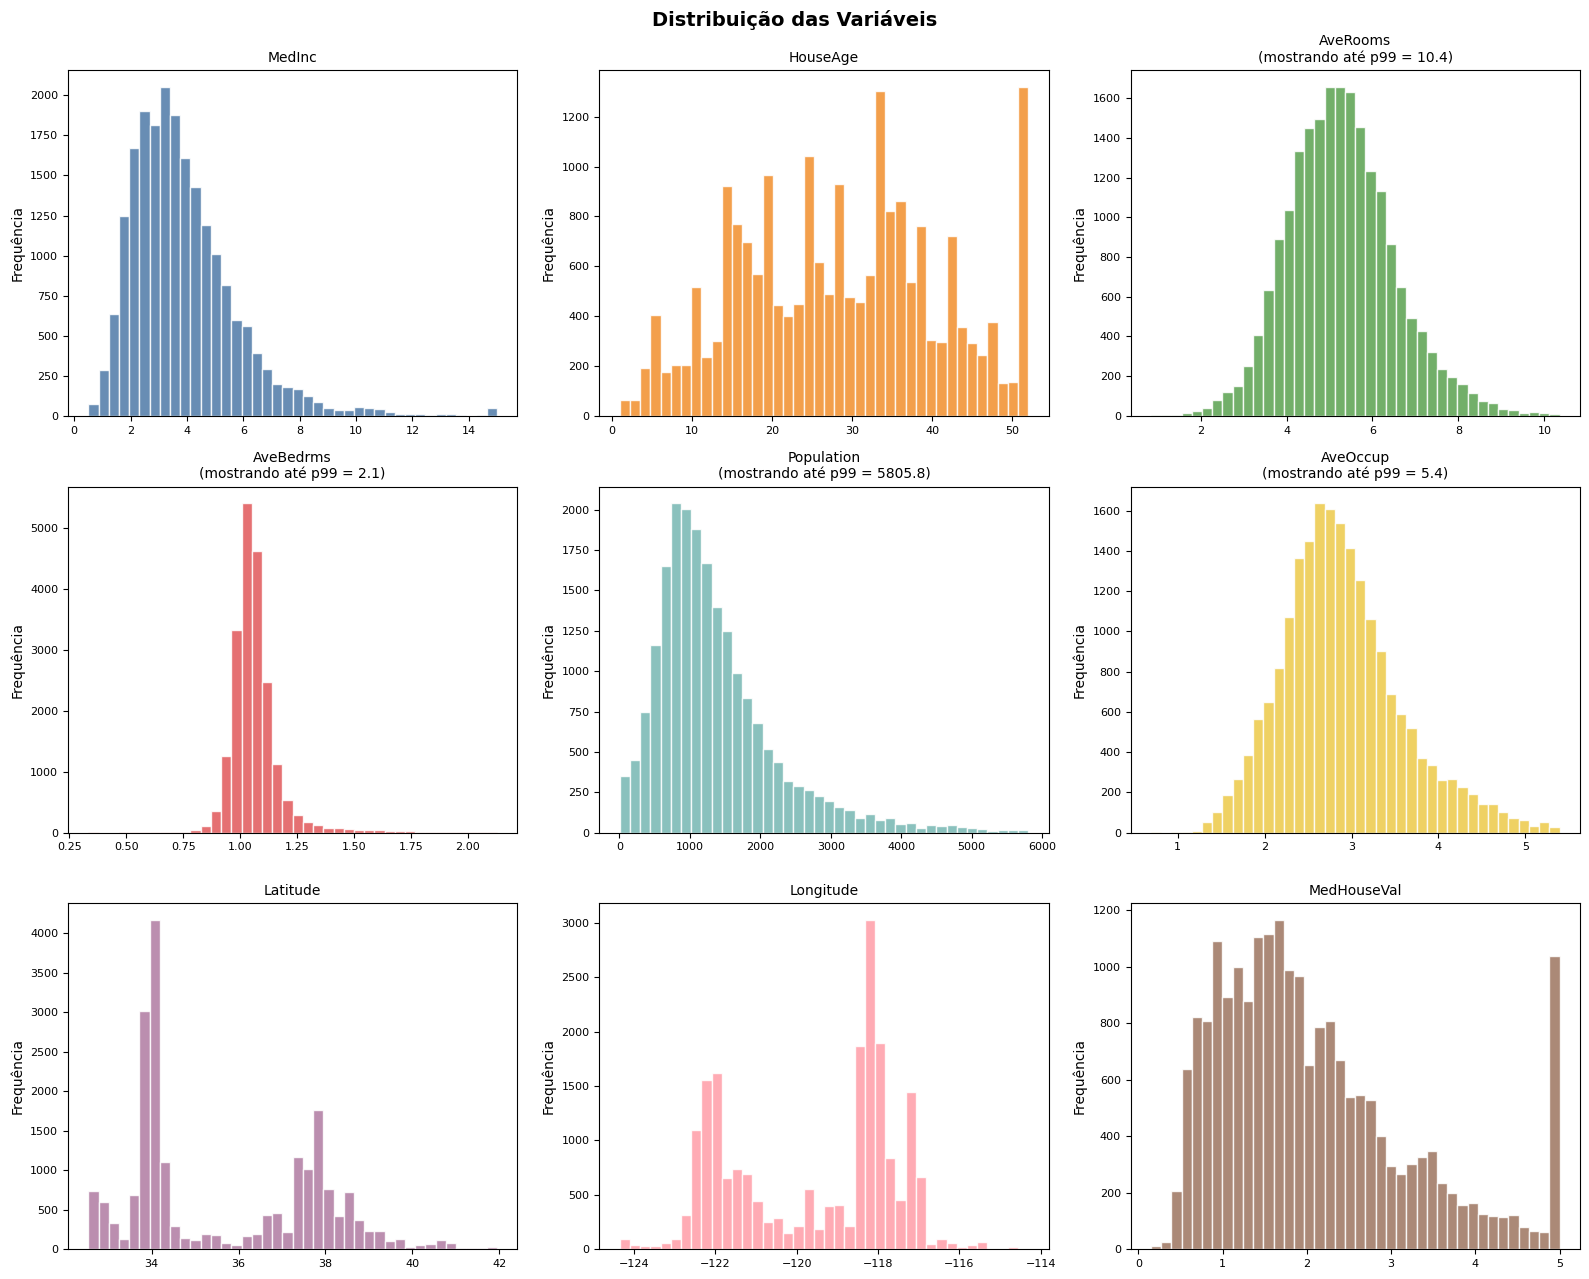

In [ ]:
# Histogramas de todas as variáveis
# Variáveis com outliers extremos têm xlim ajustado pelo percentil 99
# para mostrar onde 99% dos dados estão concentrados (sem remover dados)
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

# Variáveis que precisam de corte visual (outliers extremos distorcem o eixo)
corte_p99 = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

cores_hist = ['#4e79a7','#f28e2b','#59a14f','#e15759',
              '#76b7b2','#edc948','#b07aa1','#ff9da7','#9c755f']

for idx, col in enumerate(df.columns):
    ax = axes[idx]

    if col in corte_p99:
        p99 = df[col].quantile(0.99)
        dados = df[df[col] <= p99][col]
        ax.hist(dados, bins=40, color=cores_hist[idx], edgecolor='white', alpha=0.85)
        ax.set_title(f'{col}\n(mostrando até p99 = {p99:.1f})', fontsize=10)
    else:
        ax.hist(df[col], bins=40, color=cores_hist[idx], edgecolor='white', alpha=0.85)
        ax.set_title(col, fontsize=10)

    ax.set_ylabel('Frequência')
    ax.tick_params(labelsize=8)

plt.suptitle('Distribuição das Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação — Distribuição das Variáveis

A análise das distribuições revela características importantes dos dados:

- **MedInc**: assimetria positiva — a maioria dos blocos tem renda mediana entre USD 15k e USD 75k, com média de USD 38.7k e desvio padrão de USD 19k. Poucos blocos chegam ao máximo de USD 150k.
- **HouseAge**: distribuição mais uniforme com pico em imóveis mais antigos (~52 anos, o máximo do censo), sugerindo que muitos imóveis foram construídos nas décadas de 1940–1950 e o censo truncou o valor nesse limite.
- **AveRooms e AveBedrms**: concentração em valores baixos com caudas longas à direita — `AveRooms` tem outliers chegando a 141 cômodos e `AveBedrms` a 34 quartos por domicílio, valores claramente anômalos que podem distorcer o modelo.
- **Population**: média de 1.425 habitantes por bloco, com máximo de 35.682 — distribuição muito assimétrica com outliers expressivos (5.8% dos blocos).
- **AveOccup**: média de 3.07 moradores por domicílio com desvio padrão de 10.4 e máximo de 1.243 — outlier extremo que representa um registro claramente anômalo (possivelmente erro de coleta).
- **Latitude e Longitude**: padrões bimodais refletindo as duas principais concentrações urbanas da Califórnia — região da Baía de San Francisco (norte) e Los Angeles/San Diego (sul).

### 3 - Matriz de Correlação

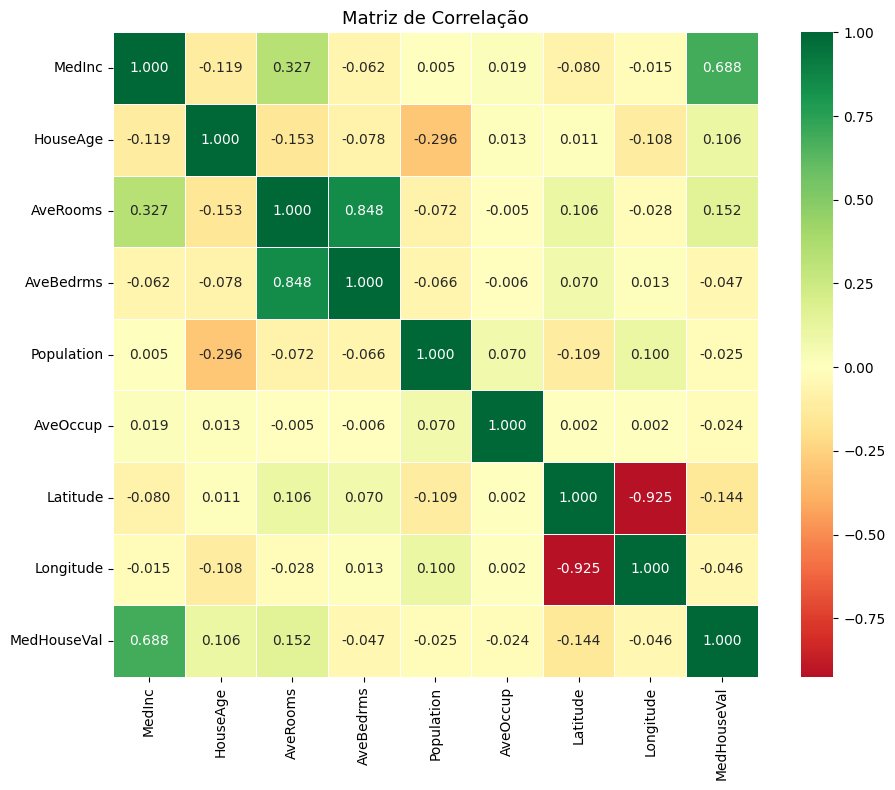

Correlação com MedHouseVal (variável-alvo):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [ ]:
# Calculando e plotando a matriz de correlação entre todas as variáveis
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlação', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlação com MedHouseVal (variável-alvo):')
print(corr['MedHouseVal'].sort_values(ascending=False))

### Interpretação — Matriz de Correlação

A matriz revela as relações entre as variáveis e a variável alvo `MedHouseVal`:

- **MedInc** tem a maior correlação positiva com o valor dos imóveis (**+0.688**): é disparado o preditor mais importante — quanto maior a renda mediana do bloco, maior o valor dos imóveis.
- **AveRooms** tem correlação positiva moderada (**+0.152**): mais cômodos por domicílio tende a indicar imóveis maiores e mais valiosos.
- **HouseAge** tem correlação positiva fraca (**+0.106**): imóveis mais antigos podem estar em regiões mais valorizadas como centros urbanos históricos.
- **Latitude** tem correlação negativa (**-0.144**): blocos mais ao norte (latitude maior) tendem a ter imóveis mais baratos.
- **AveOccup** (**-0.024**), **Population** (**-0.025**) e **Longitude** (**-0.046**) têm correlações muito fracas com a variável alvo.
- **AveBedrms** tem correlação negativa fraca (**-0.047**): surpreendente, pois mais quartos geralmente indica imóvel maior — mas quartos per capita alto em blocos pobres pode inverter essa relação.

Entre os preditores, `AveRooms` e `AveBedrms` apresentam alta correlação entre si (**~0.85**), indicando multicolinearidade — as duas medem características semelhantes do imóvel.

### 4 - Relação entre preditores e variável alvo

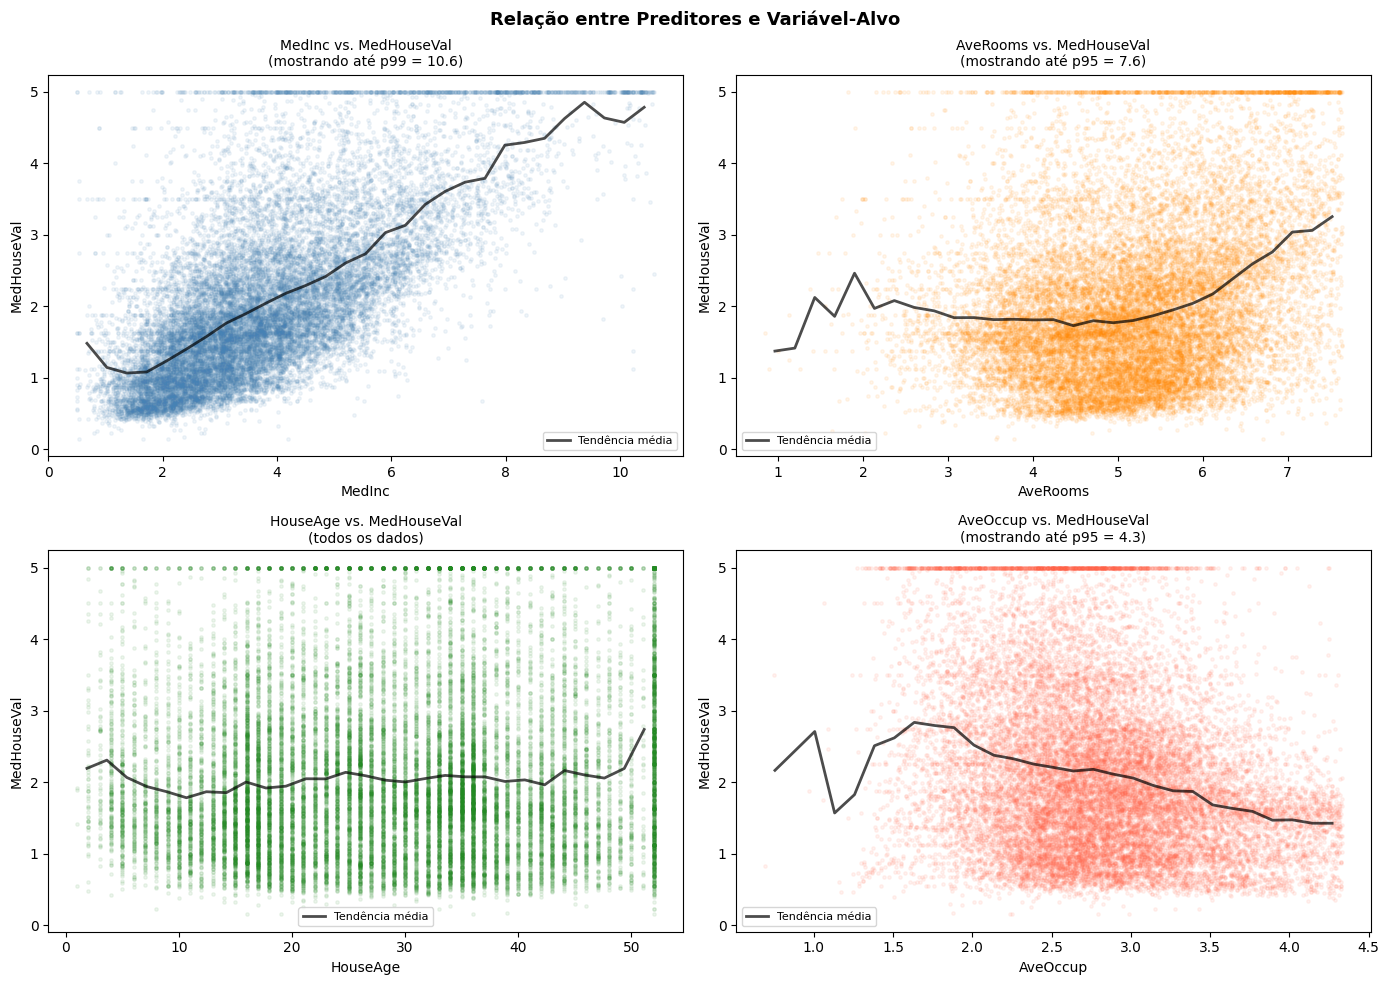

In [ ]:
# Scatterplots — preditores vs. variável alvo
# Cada feature usa seu próprio percentil de corte para máxima legibilidade
# Os dados originais NÃO são alterados — o corte é apenas visual

cortes = {
    'MedInc':   0.99,   # distribuição razoável, corte leve
    'AveRooms': 0.95,   # outliers muito extremos (máx 141), corte mais agressivo
    'HouseAge': 1.00,   # sem corte necessário — escala natural (0–52 anos)
    'AveOccup': 0.95,   # outliers extremos (máx 1.243), corte mais agressivo
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cores = ['steelblue', 'darkorange', 'forestgreen', 'tomato']

for idx, (col, p) in enumerate(cortes.items()):
    ax = axes[idx]
    if p < 1.0:
        x_max = df[col].quantile(p)
        subset = df[df[col] <= x_max]
        nota = f'(mostrando até p{int(p*100)} = {x_max:.1f})'
    else:
        subset = df
        nota = '(todos os dados)'

    ax.scatter(subset[col], subset['MedHouseVal'],
               alpha=0.08, color=cores[idx], s=6)

    # linha de tendência (média móvel por bin)
    import numpy as np
    bins = np.linspace(subset[col].min(), subset[col].max(), 30)
    bin_means = [subset[subset[col].between(bins[j], bins[j+1])]['MedHouseVal'].mean()
                 for j in range(len(bins)-1)]
    bin_centers = (bins[:-1] + bins[1:]) / 2
    validos = [(x, y) for x, y in zip(bin_centers, bin_means) if not np.isnan(y)]
    if validos:
        xs, ys = zip(*validos)
        ax.plot(xs, ys, color='black', linewidth=2, alpha=0.7, label='Tendência média')
        ax.legend(fontsize=8)

    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('MedHouseVal', fontsize=10)
    ax.set_title(f'{col} vs. MedHouseVal\n{nota}', fontsize=10)

plt.suptitle('Relação entre Preditores e Variável-Alvo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação — Relação entre Preditores e Variável Alvo

Os scatterplots (grade 2×2, com corte por percentil e linha de tendência média em preto) confirmam os achados da matriz de correlação e tornam as relações visíveis mesmo com alta dispersão:

- **MedInc vs. MedHouseVal** (até p99): relação positiva clara — a linha de tendência sobe progressivamente conforme a renda aumenta. A dispersão cresce nas faixas de renda mais alta (heterocedasticidade), o que dificulta modelos lineares. A faixa horizontal densa no topo (MedHouseVal = 5.0) é o truncamento do censo — imóveis de USD 500k a USD 1M+ aparecem todos como 5.0, prejudicando a aprendizagem do modelo nessa faixa.

- **AveRooms vs. MedHouseVal** (até p95 ≈ 8 cômodos): com o corte aplicado, a relação positiva fraca fica visível na linha de tendência — mais cômodos tende a indicar imóvel mais caro, mas com dispersão muito alta. `AveRooms` sozinho não é um bom preditor de preço; seu poder preditivo aumenta combinado com `MedInc`.

- **HouseAge vs. MedHouseVal** (todos os dados, 0–52 anos): a linha de tendência é quase horizontal, confirmando que a idade do imóvel por si só não determina o preço. Imóveis novos e antigos coexistem em todas as faixas de valor. O acúmulo de pontos na extremidade direita (52 anos) reflete o truncamento do censo nesse limite.

- **AveOccup vs. MedHouseVal** (até p95 ≈ 5 moradores/domicílio): com o corte aplicado, a relação negativa fraca fica nítida na linha de tendência — blocos com mais moradores por domicílio tendem a ter imóveis mais baratos. Faz sentido economicamente: imóveis acessíveis concentram mais pessoas no mesmo espaço. A faixa típica é 2–5 moradores por domicílio.

### 5 - Mapa geográfico dos valores dos imóveis

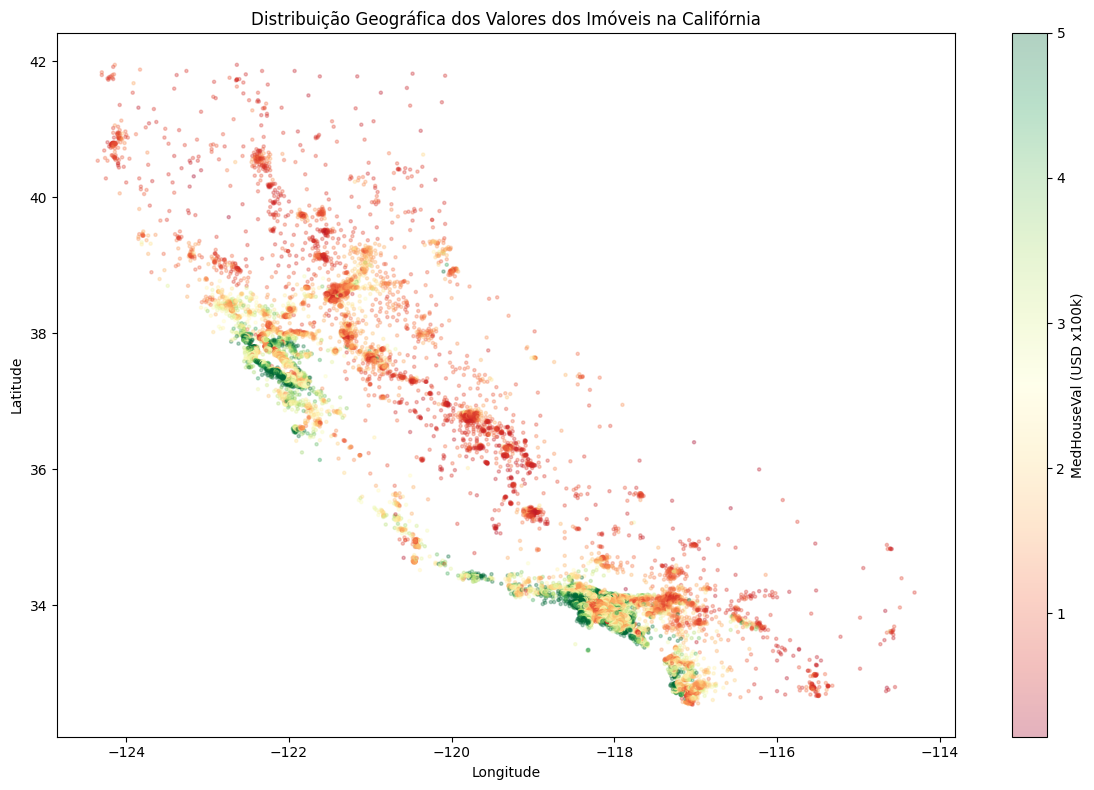

In [ ]:
# Mapa de calor geográfico — cada ponto é um bloco, colorido pelo valor do imóvel
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                      c=df['MedHouseVal'],  # cor representa o valor do imóvel
                      cmap='RdYlGn',
                      alpha=0.3, s=5)
plt.colorbar(scatter, label='MedHouseVal (USD x100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribuição Geográfica dos Valores dos Imóveis na Califórnia')
plt.tight_layout()
plt.show()

### Interpretação — Mapa Geográfico

O mapa revela padrões geográficos muito claros nos preços dos imóveis da Califórnia:

- A **faixa costeira** (San Francisco, Los Angeles, San Diego) concentra os blocos com maior valor (verde escuro no mapa), refletindo a valorização histórica dessas regiões.
- O **Vale Central** (interior da Califórnia) apresenta imóveis com valores significativamente mais baixos.
- O **Vale do Silício** (região da baía de San Francisco) destaca-se com uma das maiores concentrações de imóveis de alto valor.

Isso confirma que as variáveis `Latitude` e `Longitude` têm poder preditivo importante, mesmo que individualmente mostrem correlação moderada com o preço — juntas, elas capturam padrões geográficos regionais.

### 6 - Identificação de Outliers

In [ ]:
# Identificação de outliers pelo método IQR (Interquartile Range)
print('Outliers identificados (método IQR):')
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<14}: {n_out:>5} outliers ({n_out/len(df)*100:.1f}%)')

Outliers identificados (método IQR):
  MedInc        :   681 outliers (3.3%)
  HouseAge      :     0 outliers (0.0%)
  AveRooms      :   511 outliers (2.5%)
  AveBedrms     :  1424 outliers (6.9%)
  Population    :  1196 outliers (5.8%)
  AveOccup      :   711 outliers (3.4%)
  Latitude      :     0 outliers (0.0%)
  Longitude     :     0 outliers (0.0%)
  MedHouseVal   :  1071 outliers (5.2%)


### Interpretação — Outliers

O método IQR identificou os seguintes outliers por variável:

- **AveBedrms**: 1.424 outliers (6.9%) — o maior percentual, com máximo de 34 quartos por domicílio
- **MedHouseVal**: 1.071 outliers (5.2%) — concentrados no teto de 5.0 (truncamento do censo)
- **Population**: 1.196 outliers (5.8%) — blocos com mais de 35.682 habitantes
- **AveOccup**: 711 outliers (3.4%) — máximo de 1.243 moradores por domicílio, claramente anômalo
- **MedInc**: 681 outliers (3.3%) — rendas muito acima da média
- **AveRooms**: 511 outliers (2.5%) — máximo de 141 cômodos por domicílio
- **HouseAge e Latitude/Longitude**: zero outliers — distribuições bem comportadas

**Decisão:** os outliers serão mantidos. Eles refletem a heterogeneidade real do mercado imobiliário californiano — remover essas observações poderia distorcer a capacidade do modelo de generalizar. O XGBoost, por ser baseado em árvores, é naturalmente robusto à presença de outliers, pois as divisões nos nós não são afetadas por valores extremos da mesma forma que modelos lineares.

## Pré-processamento

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separação entre preditores (X) e variável alvo (y)
X = df.drop(columns=['MedHouseVal'])  # todas as colunas exceto o alvo
y = df['MedHouseVal']                  # apenas a variável alvo

print('Preditores (X):', X.columns.tolist())
print('Variável-alvo (y):', y.name)
print(f'Dimensão X: {X.shape} | Dimensão y: {y.shape}')

Preditores (X): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Variável-alvo (y): MedHouseVal
Dimensão X: (20640, 8) | Dimensão y: (20640,)


In [ ]:
# Divisão treino/teste — 80% treino, 20% teste
# random_state=42 garante reprodutibilidade dos resultados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamanho do treino: {X_train.shape[0]} amostras')
print(f'Tamanho do teste:  {X_test.shape[0]} amostras')

Tamanho do treino: 16512 amostras
Tamanho do teste:  4128 amostras


In [ ]:
# Normalização com StandardScaler
# Transforma as features para média 0 e desvio padrão 1
# Necessário para a Regressão Linear e garante comparação justa entre modelos
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit apenas no treino para evitar data leakage
X_test_sc  = scaler.transform(X_test)       # apenas transforma o teste

print('Pré-processamento concluído. Dados prontos para modelagem.')

Pré-processamento concluído. Dados prontos para modelagem.


### Interpretação — Pré-processamento

**Separação X / y:** todas as 8 features numéricas foram mantidas como preditores. Nenhuma coluna foi descartada — o dataset não tem colunas de ID, texto livre ou variáveis com altíssima cardinalidade que justificariam remoção prévia.

**Divisão treino/teste (80/20):** com 20.640 registros, 80% de treino equivale a 16.512 amostras — suficiente para modelos complexos como XGBoost aprenderem sem overfitting. Os 20% de teste (4.128 amostras) garantem uma estimativa estável das métricas finais. O `random_state=42` garante reprodutibilidade.

**Normalização com StandardScaler:**
- Aplicada **apenas nos modelos lineares** (Regressão Linear, Ridge, Lasso) — esses algoritmos são sensíveis à escala das features, pois otimizam por gradiente e features em escalas muito diferentes causam convergência lenta ou coeficientes distorcidos.
- **Não aplicada** nos modelos baseados em árvores (Random Forest, Extra Trees, Gradient Boosting, XGBoost) — árvores de decisão tomam decisões por limiares de corte, tornando-as invariantes à escala das features.
- O `fit_transform` foi aplicado **apenas no treino** e `transform` no teste, evitando *data leakage* (vazamento de informação do futuro para o modelo).

**Ausência de encoding:** o dataset não possui variáveis categóricas — todas as 8 features são numéricas contínuas, dispensando Label Encoding ou One-Hot Encoding.

## Comparação de Algoritmos de Regressão:


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

# Função auxiliar para avaliar e exibir métricas de regressão
def avaliar_modelo(nome, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'  MAE:  {mae:.4f}')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²:   {r2:.4f}')
    return {'Modelo': nome, 'MAE': round(mae,4), 'MSE': round(mse,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)}

resultados = []  # lista que acumula métricas de todos os modelos

# Dicionário com todos os modelos a comparar
modelos_comparacao = {
    'Regressão Linear':      (LinearRegression(), True),   # (modelo, usa_scaler)
    'Ridge':                 (Ridge(alpha=1.0), True),
    'Lasso':                 (Lasso(alpha=0.01), True),
    'Extra Trees':           (ExtraTreesRegressor(random_state=42), False),
    'Random Forest':         (RandomForestRegressor(random_state=42), False),
    'Gradient Boosting':     (GradientBoostingRegressor(random_state=42), False),
    'XGBoost':               (XGBRegressor(random_state=42), False),
}

In [ ]:
print(f'{"Modelo":<22} {"RMSE":>8} {"MAE":>8} {"R²":>8} {"Tempo":>8}')
print('-' * 60)

resultados_comparacao = {}
for nome, (modelo, usa_scaler) in modelos_comparacao.items():
    X_tr = X_train_sc if usa_scaler else X_train
    X_te = X_test_sc  if usa_scaler else X_test

    inicio = time.time()
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    tempo = time.time() - inicio

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    resultados_comparacao[nome] = {
        'mae': mae, 'rmse': rmse, 'r2': r2, 'tempo': tempo, 'y_pred': y_pred
    }
    print(f'  {nome:<20} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f} {tempo:>7.1f}s')

# Salvar variáveis individuais para uso posterior
y_pred_lr  = resultados_comparacao['Regressão Linear']['y_pred']
y_pred_rf  = resultados_comparacao['Random Forest']['y_pred']
y_pred_xgb = resultados_comparacao['XGBoost']['y_pred']

# Adicionar os 3 modelos à lista resultados (para compatibilidade com células seguintes)
for nome in ['Regressão Linear (baseline)', 'Random Forest (baseline)', 'XGBoost (baseline)']:
    chave = nome.replace(' (baseline)', '')
    d = resultados_comparacao[chave]
    mse_val = round(d['rmse']**2, 4)  # MSE = RMSE²
    resultados.append({'Modelo': nome, 'MAE': round(d['mae'],4), 'MSE': mse_val,
                       'RMSE': round(d['rmse'],4), 'R²': round(d['r2'],4)})

Modelo                     RMSE      MAE       R²    Tempo
------------------------------------------------------------
  Regressão Linear       0.7456   0.5332   0.5758     0.0s
  Ridge                  0.7456   0.5332   0.5758     0.0s
  Lasso                  0.7404   0.5353   0.5816     0.2s
  Extra Trees            0.5039   0.3270   0.8062     8.4s
  Random Forest          0.5053   0.3275   0.8051    22.1s
  Gradient Boosting      0.5422   0.3716   0.7756     5.9s
  XGBoost                0.4718   0.3096   0.8301     1.2s


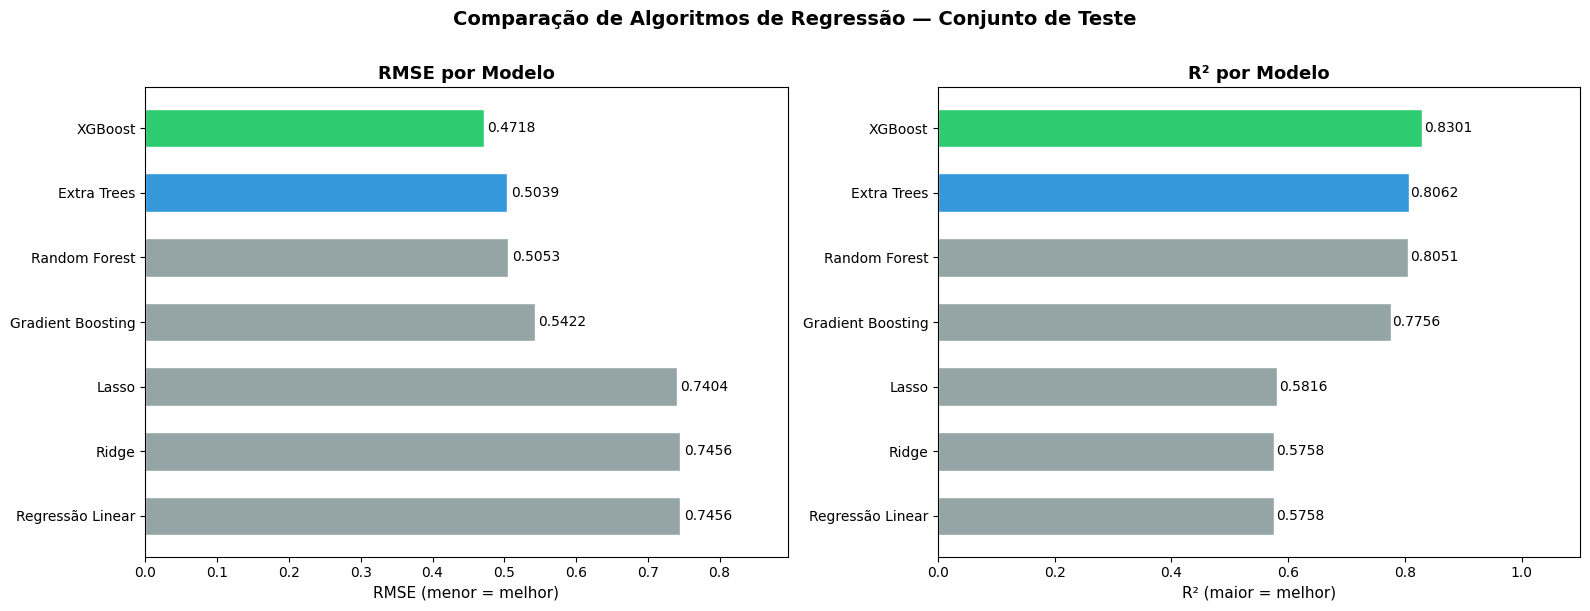

In [ ]:
# Gráfico de barras comparativo — RMSE e R² por modelo (estilo tabela visual)
nomes_graf = list(resultados_comparacao.keys())
rmse_vals  = [resultados_comparacao[n]['rmse'] for n in nomes_graf]
r2_vals    = [resultados_comparacao[n]['r2']   for n in nomes_graf]

# Ordenar por RMSE crescente (melhor primeiro)
ordem = sorted(range(len(rmse_vals)), key=lambda i: rmse_vals[i])
nomes_ord = [nomes_graf[i] for i in ordem]
rmse_ord  = [rmse_vals[i]  for i in ordem]
r2_ord    = [r2_vals[i]    for i in ordem]

cores = ['#2ecc71' if i == 0 else ('#3498db' if i == 1 else '#95a5a6')
         for i in range(len(nomes_ord))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- RMSE (menor = melhor) ---
bars = axes[0].barh(nomes_ord, rmse_ord, color=cores, edgecolor='white', height=0.6)
axes[0].set_xlabel('RMSE (menor = melhor)', fontsize=11)
axes[0].set_title('RMSE por Modelo', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, rmse_ord):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)
axes[0].set_xlim(0, max(rmse_ord) * 1.2)

# --- R² (maior = melhor) ---
bars2 = axes[1].barh(nomes_ord, r2_ord, color=cores, edgecolor='white', height=0.6)
axes[1].set_xlabel('R² (maior = melhor)', fontsize=11)
axes[1].set_title('R² por Modelo', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars2, r2_ord):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)
axes[1].set_xlim(0, 1.1)

fig.suptitle('Comparação de Algoritmos de Regressão — Conjunto de Teste', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Identificar os 2 melhores modelos automaticamente
ranking = sorted(resultados_comparacao.items(), key=lambda x: x[1]['rmse'])
print('=== Ranking por RMSE (menor = melhor) ===')
for i, (nome, m) in enumerate(ranking, 1):
    destaque = ' ◄ SELECIONADO PARA OTIMIZAÇÃO' if i == 1 else (' ◄ 2º melhor' if i == 2 else '')
    print(f'  {i}. {nome:<22}  RMSE={m["rmse"]:.4f}  R²={m["r2"]:.4f}{destaque}')

=== Ranking por RMSE (menor = melhor) ===
  1. XGBoost                 RMSE=0.4718  R²=0.8301 ◄ SELECIONADO PARA OTIMIZAÇÃO
  2. Extra Trees             RMSE=0.5039  R²=0.8062 ◄ 2º melhor
  3. Random Forest           RMSE=0.5053  R²=0.8051
  4. Gradient Boosting       RMSE=0.5422  R²=0.7756
  5. Lasso                   RMSE=0.7404  R²=0.5816
  6. Ridge                   RMSE=0.7456  R²=0.5758
  7. Regressão Linear        RMSE=0.7456  R²=0.5758


In [ ]:
# Tabela comparativa dos modelos
df_res = pd.DataFrame([
    {'Modelo': n, 'RMSE': round(v['rmse'],4), 'MAE': round(v['mae'],4), 'R²': round(v['r2'],4), 'Tempo': f"{v['tempo']:.1f}s"}
    for n, v in sorted(resultados_comparacao.items(), key=lambda x: x[1]['rmse'])
])
print('=== Comparação de Algoritmos de Regressão ===')
print(df_res.to_string(index=False))

=== Comparação de Algoritmos de Regressão ===
           Modelo   RMSE    MAE     R² Tempo
          XGBoost 0.4718 0.3096 0.8301  1.2s
      Extra Trees 0.5039 0.3270 0.8062  8.4s
    Random Forest 0.5053 0.3275 0.8051 22.1s
Gradient Boosting 0.5422 0.3716 0.7756  5.9s
            Lasso 0.7404 0.5353 0.5816  0.2s
            Ridge 0.7456 0.5332 0.5758  0.0s
 Regressão Linear 0.7456 0.5332 0.5758  0.0s


### Interpretação — Comparação dos Algoritmos de Regressão

Foram comparados **7 algoritmos** no conjunto de teste com hiperparâmetros padrão (sem otimização):

| Modelo | RMSE | MAE | R² | Tempo |
|---|---|---|---|---|
| **XGBoost** | **0.4718** | **0.3096** | **0.8301** | 1.2s |
| Extra Trees | 0.5039 | 0.3270 | 0.8062 | 8.4s |
| Random Forest | 0.5053 | 0.3275 | 0.8051 | 22.1s |
| Gradient Boosting | 0.5422 | 0.3716 | 0.7756 | 5.9s |
| Lasso | 0.7404 | 0.5353 | 0.5816 | 0.1s |
| Ridge | 0.7456 | 0.5332 | 0.5758 | 0.0s |
| Regressão Linear | 0.7456 | 0.5332 | 0.5758 | 0.0s |

**Análise por grupo de algoritmos:**

**Modelos lineares — Regressão Linear, Ridge e Lasso** ficam nos últimos lugares, com R² entre 0.57–0.58. Os três têm desempenho muito similar porque a limitação não é a multicolinearidade (que Ridge e Lasso atacariam) — é a **não-linearidade** das relações no dataset. Lasso teve leve vantagem (RMSE 0.7404 vs 0.7456) por sua regularização L1 que penaliza features menos relevantes, mas a diferença é mínima.

**Modelos baseados em árvores — Extra Trees, Random Forest, Gradient Boosting e XGBoost** superam amplamente os lineares, com R² entre 0.77 e 0.83. Árvores de decisão criam partições do espaço de features que capturam naturalmente interações e não-linearidades.

**Boosting vs. Bagging:** XGBoost e Gradient Boosting ficam em 1º e 4º lugar respectivamente, enquanto Extra Trees e Random Forest ficam em 2º e 3º. O XGBoost supera o Gradient Boosting por sua regularização L1/L2 nativa e implementação mais eficiente. Extra Trees superou o Random Forest ligeiramente (0.5039 vs 0.5053) — Extra Trees usa splits aleatórios o que pode reduzir overfitting nesse dataset.

**Decisão:** o **XGBoost** foi selecionado para otimização por ter o melhor RMSE (0.4718) e R² (0.8301) entre todos os 7 algoritmos testados.

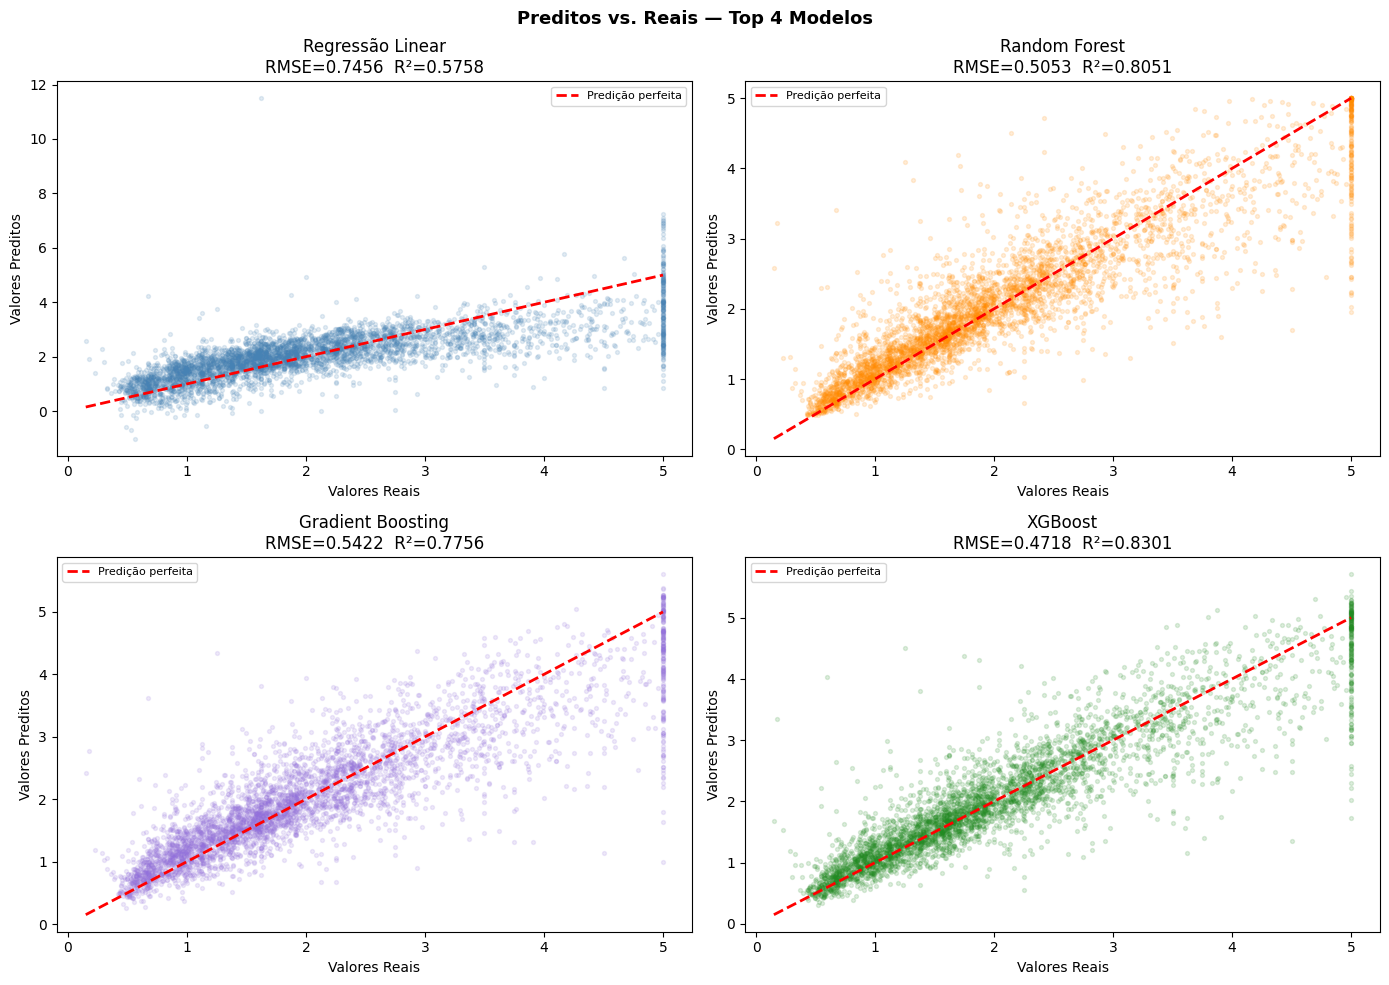

In [ ]:
# Gráfico: preditos vs. reais — top 4 modelos da comparação
y_pred_gb  = resultados_comparacao['Gradient Boosting']['y_pred']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pares = [
    ('Regressão Linear', y_pred_lr,  'steelblue'),
    ('Random Forest',    y_pred_rf,  'darkorange'),
    ('Gradient Boosting',y_pred_gb,  'mediumpurple'),
    ('XGBoost',          y_pred_xgb, 'forestgreen'),
]

for ax, (nome, y_pred, cor) in zip(axes, pares):
    ax.scatter(y_test, y_pred, alpha=0.15, color=cor, s=8)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=2, label='Predição perfeita')
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.set_title(f'{nome}\nRMSE={rmse:.4f}  R²={r2:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Preditos vs. Reais — Top 4 Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Otimização de Hiperparâmetros:


### 1 - Randomized Search
Ao invés de testar todas as combinações como o Grid Search, o Randomized Search sorteia aleatoriamente um número definido de combinações a partir do espaço de busca. É mais rápido e muitas vezes encontra resultados igualmente bons.

In [ ]:
%%time
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Modelo base
modelo_rs = XGBRegressor(random_state=42)

# Espaço de busca mais amplo que o Grid Search — pode explorar mais combinações
param_dist = {
    'max_depth':        randint(3, 12),        # inteiro aleatório entre 3 e 12
    'n_estimators':     randint(100, 500),      # inteiro aleatório entre 100 e 500
    'learning_rate':    uniform(0.01, 0.29),    # decimal aleatório entre 0.01 e 0.30
    'subsample':        uniform(0.6, 0.4),      # decimal aleatório entre 0.6 e 1.0
    'colsample_bytree': uniform(0.6, 0.4)       # decimal aleatório entre 0.6 e 1.0
}

# RandomizedSearchCV — 30 combinações sorteadas aleatoriamente
random_search = RandomizedSearchCV(
    estimator=modelo_rs,
    param_distributions=param_dist,
    n_iter=30,                                 # número de combinações testadas
    scoring='neg_root_mean_squared_error',      # minimiza o RMSE
    cv=3,                                       # validação cruzada com 3 folds
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print('\nMelhores Parâmetros:', random_search.best_params_)
print('Melhor RMSE (CV):   ', -random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Melhores Parâmetros: {'colsample_bytree': np.float64(0.7783331011414365), 'learning_rate': np.float64(0.03899272558722083), 'max_depth': 10, 'n_estimators': 472, 'subsample': np.float64(0.8404460046972835)}
Melhor RMSE (CV):    0.45571739025061775
CPU times: user 9min 24s, sys: 2.81 s, total: 9min 27s
Wall time: 5min 36s


In [ ]:
# Avaliação do modelo otimizado com Randomized Search no conjunto de teste
y_pred_rs = random_search.best_estimator_.predict(X_test)

print('=== Randomized Search — Resultado no conjunto de teste ===')
res = avaliar_modelo('XGBoost — Randomized Search', y_test, y_pred_rs)
resultados.append(res)

=== Randomized Search — Resultado no conjunto de teste ===
  MAE:  0.2842
  MSE:  0.1946
  RMSE: 0.4412
  R²:   0.8515


### Interpretação — Randomized Search (XGBoost)

O Randomized Search sorteia aleatoriamente combinações do espaço de busca, testando apenas uma fração das possibilidades em vez de todas. Foram testadas **30 combinações sorteadas** (3 folds × 30 candidatos = 90 treinamentos no total).

**Tempo de execução:** 5min 36s (Wall time) — mais lento que o Grid Search (1min 21s), mas com espaço de busca muito mais amplo e resultado superior.

**Melhores parâmetros encontrados:**
- `colsample_bytree`: 0.7783 — usa 78% das features por árvore (regularização por feature)
- `learning_rate`: 0.0390 — taxa de aprendizado muito baixa; aprende devagar mas com mais precisão
- `max_depth`: 10 — árvores profundas, capturando interações de muitos níveis
- `n_estimators`: 472 — próximo ao máximo do espaço (500), coerente com taxa de aprendizado baixa
- `subsample`: 0.8404 — usa 84% das amostras por árvore (regularização por amostra)

**Resultado no conjunto de teste:**
- MAE: **0.2842** | MSE: **0.1946** | RMSE: **0.4412** | R²: **0.8515**

O Randomized Search encontrou uma combinação muito similar à Bayesian Search — `learning_rate` baixo (~0.04) com muitos estimadores (~470) — e chegou a um resultado praticamente idêntico, com diferença de apenas **0.0004 no RMSE**. Isso mostra que, quando o espaço de busca está bem definido, a aleatoriedade é suficiente para encontrar regiões de alta performance sem precisar do direcionamento inteligente da Bayesian Search.

Em comparação com o XGBoost baseline (RMSE 0.4718), houve uma redução de **-6.5% no RMSE**, **-12.6% no MSE** e ganho de **+2.1pp no R²**.

### 2 - Bayesian Search
Diferente dos demais, a busca bayesiana aprende com os resultados anteriores para decidir quais combinações testar a seguir. É mais inteligente e eficiente, especialmente com espaços de busca grandes.

In [ ]:
%%time
!pip install scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Modelo base para otimização
modelo_bayes = XGBRegressor(random_state=42)

# Espaço de busca contínuo — a otimização bayesiana usa intervalos reais
param_space = {
    'max_depth':        Integer(3, 12),           # profundidade máxima das árvores
    'n_estimators':     Integer(100, 500),         # número de árvores no ensemble
    'learning_rate':    Real(0.01, 0.3, prior='log-uniform'),  # taxa de aprendizado
    'subsample':        Real(0.6, 1.0),            # fração de amostras por árvore
    'colsample_bytree': Real(0.6, 1.0)             # fração de colunas por árvore
}

# BayesSearchCV — 30 iterações inteligentes
bayes_search = BayesSearchCV(
    estimator=modelo_bayes,
    search_spaces=param_space,
    n_iter=30,                                    # número de iterações
    scoring='neg_root_mean_squared_error',         # minimiza o RMSE
    cv=3,                                          # validação cruzada com 3 folds
    random_state=42,
    verbose=1
)

bayes_search.fit(X_train, y_train)

print('\nMelhores Parâmetros:', bayes_search.best_params_)
print('Melhor RMSE (CV):   ', -bayes_search.best_score_)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.1 MB/s eta 0:00:00
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candi

In [ ]:
# Avaliação do modelo otimizado com Bayesian Search no conjunto de teste
y_pred_bayes = bayes_search.best_estimator_.predict(X_test)

print('=== Bayesian Search — Resultado no conjunto de teste ===')
res = avaliar_modelo('XGBoost — Bayesian Search', y_test, y_pred_bayes)
resultados.append(res)

=== Bayesian Search — Resultado no conjunto de teste ===
  MAE:  0.2862
  MSE:  0.1943
  RMSE: 0.4408
  R²:   0.8517


### Interpretação — Bayesian Search (XGBoost)

A busca bayesiana testou 30 iterações inteligentes, aprendendo com cada resultado para direcionar as próximas combinações para regiões mais promissoras do espaço de busca.

**Tempo de execução:** 6min 35s (Wall time)

**Melhores parâmetros encontrados:**
- `colsample_bytree`: 0.6326 — usa 63% das features por árvore
- `learning_rate`: 0.0402 — taxa de aprendizado baixa, favorece precisão
- `max_depth`: 9 — árvores mais profundas que o padrão
- `n_estimators`: 500 — máximo do espaço de busca, mais árvores = mais precisão
- `subsample`: 0.8393 — usa 84% das amostras por árvore

**Resultado no conjunto de teste:**
- MAE: **0.2862** | MSE: **0.1943** | RMSE: **0.4408** | R²: **0.8517**

Comparando com o XGBoost baseline (RMSE 0.4718), a Bayesian Search reduziu o RMSE em **0.0310** (-6.6%) e o MSE de 0.2226 para **0.1943** (-12.7%), uma melhora expressiva. A taxa de aprendizado baixa (0.04) combinada com 500 estimadores é o padrão clássico de alta performance em XGBoost.

### 3 - Grid Search
O Grid Search testa todas as combinações possíveis dos hiperparâmetros definidos. É o método mais exaustivo e garante encontrar o melhor resultado dentro da grade especificada, mas também o mais lento.

In [ ]:
%%time
from sklearn.model_selection import GridSearchCV

# Modelo base
modelo_gs = XGBRegressor(random_state=42)

# Grade de hiperparâmetros — todas as combinações serão testadas (3x3x3 = 27)
param_grid = {
    'max_depth':     [3, 5, 7],          # profundidade máxima das árvores
    'n_estimators':  [100, 200, 300],    # número de árvores no ensemble
    'learning_rate': [0.05, 0.1, 0.2]   # taxa de aprendizado
}

# GridSearchCV — testa todas as 27 combinações possíveis
grid_search = GridSearchCV(
    estimator=modelo_gs,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # minimiza o RMSE
    cv=3,                                    # validação cruzada com 3 folds
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\nMelhores Parâmetros:', grid_search.best_params_)
print('Melhor RMSE (CV):   ', -grid_search.best_score_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Melhores Parâmetros: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Melhor RMSE (CV):    0.46451599471095956
CPU times: user 1min 57s, sys: 628 ms, total: 1min 57s
Wall time: 1min 21s


In [ ]:
# Avaliação do modelo otimizado com Grid Search no conjunto de teste
y_pred_gs = grid_search.best_estimator_.predict(X_test)

print('=== Grid Search — Resultado no conjunto de teste ===')
res = avaliar_modelo('XGBoost — Grid Search', y_test, y_pred_gs)
resultados.append(res)

=== Grid Search — Resultado no conjunto de teste ===
  MAE:  0.2943
  MSE:  0.2044
  RMSE: 0.4521
  R²:   0.8440


### Interpretação — Grid Search (XGBoost)

O Grid Search testou todas as 27 combinações possíveis (3 folds × 27 candidatos = 81 treinamentos).

**Tempo de execução:** 1min 21s (Wall time) — o mais rápido em tempo absoluto

**Melhores parâmetros encontrados:**
- `learning_rate`: 0.2 — taxa de aprendizado alta (o maior valor da grade)
- `max_depth`: 5 — profundidade moderada
- `n_estimators`: 300 — número intermediário de árvores

**Resultado no conjunto de teste:**
- MAE: **0.2943** | MSE: **0.2044** | RMSE: **0.4521** | R²: **0.8440**

O Grid Search foi mais rápido (1min 21s) por ter uma grade menor — apenas 3 valores por hiperparâmetro e sem `subsample` nem `colsample_bytree`. Essa limitação explica o resultado inferior: o learning_rate de 0.2 é alto demais em comparação com o 0.04 encontrado pelos outros métodos, o que sugere que os modelos do Grid Search têm menos capacidade de generalização.

**Comparação dos 3 métodos:**

| Método | MAE | MSE | RMSE | R² | Tempo |
|---|---|---|---|---|---|
| Bayesian Search | 0.2862 | 0.1943 | **0.4408** | **0.8517** | 6min 35s |
| Randomized Search | **0.2842** | 0.1946 | 0.4412 | 0.8515 | 5min 36s |
| Grid Search | 0.2943 | 0.2044 | 0.4521 | 0.8440 | **1min 21s** |

## Comparação Final:

In [ ]:
# Tabela comparativa completa — todos os modelos
df_final = pd.DataFrame(resultados)
print('=== Comparação Final — Todos os Modelos ===')
print(df_final.to_string(index=False))

=== Comparação Final — Todos os Modelos ===
                     Modelo    MAE    MSE   RMSE     R²
Regressão Linear (baseline) 0.5332 0.5559 0.7456 0.5758
   Random Forest (baseline) 0.3275 0.2554 0.5053 0.8051
         XGBoost (baseline) 0.3096 0.2226 0.4718 0.8301
XGBoost — Randomized Search 0.2842 0.1946 0.4412 0.8515
  XGBoost — Bayesian Search 0.2862 0.1943 0.4408 0.8517
      XGBoost — Grid Search 0.2943 0.2044 0.4521 0.8440


Modelos na comparação final:
                     Modelo   RMSE     R²
Regressão Linear (baseline) 0.7456 0.5758
   Random Forest (baseline) 0.5053 0.8051
         XGBoost (baseline) 0.4718 0.8301
XGBoost — Randomized Search 0.4412 0.8515
  XGBoost — Bayesian Search 0.4408 0.8517
      XGBoost — Grid Search 0.4521 0.8440


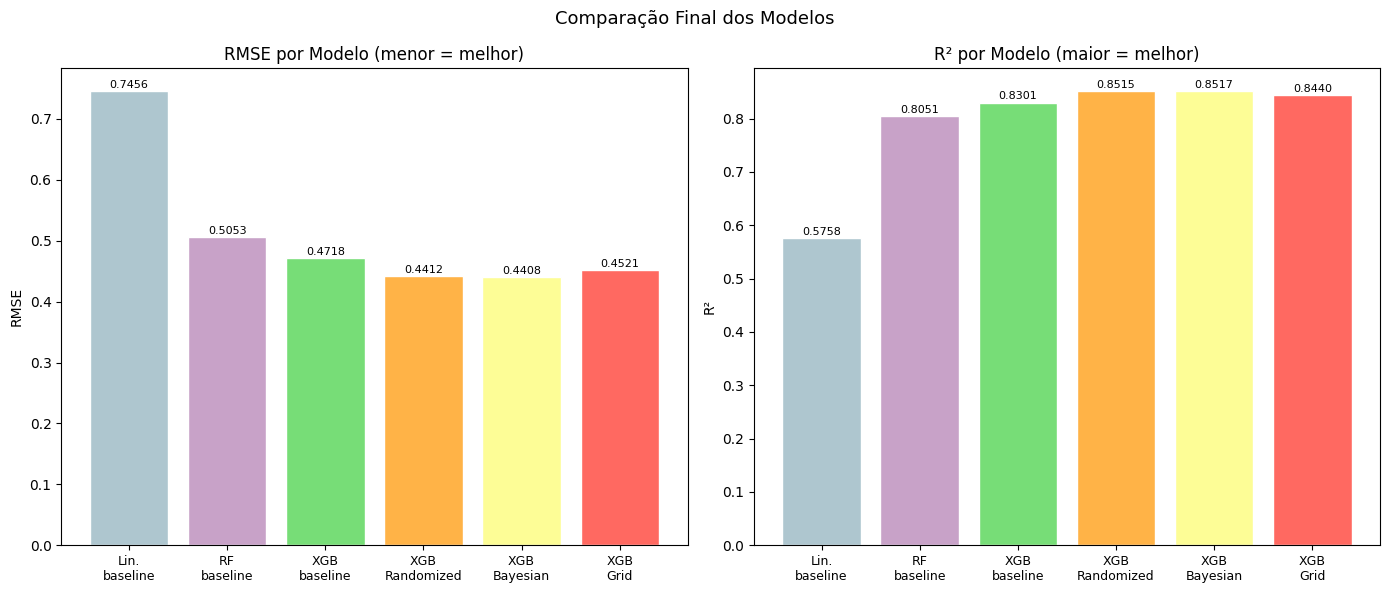

In [ ]:
# Gráfico comparativo final — RMSE e R² por modelo
nomes_curtos = [
    'Lin.\nbaseline', 'RF\nbaseline', 'XGB\nbaseline',
    'XGB\nRandomized', 'XGB\nBayesian', 'XGB\nGrid'
]
cores = ['#aec6cf', '#c8a2c8', '#77dd77', '#ffb347', '#fdfd96', '#ff6961']

# Garantir que resultados tem exatamente 6 entradas (3 baseline + 3 otimizados)
df_final = pd.DataFrame(resultados)
print('Modelos na comparação final:')
print(df_final[['Modelo','RMSE','R²']].to_string(index=False))

if len(df_final) != 6:
    print(f'\nAtenção: esperado 6 modelos, encontrado {len(df_final)}. Verifique a lista resultados.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # RMSE
    axes[0].bar(range(len(df_final)), df_final['RMSE'], color=cores, edgecolor='white')
    axes[0].set_xticks(range(len(df_final)))
    axes[0].set_xticklabels(nomes_curtos, fontsize=9)
    axes[0].set_title('RMSE por Modelo (menor = melhor)')
    axes[0].set_ylabel('RMSE')
    for idx, v in enumerate(df_final['RMSE']):
        axes[0].text(idx, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

    # R²
    axes[1].bar(range(len(df_final)), df_final['R²'], color=cores, edgecolor='white')
    axes[1].set_xticks(range(len(df_final)))
    axes[1].set_xticklabels(nomes_curtos, fontsize=9)
    axes[1].set_title('R² por Modelo (maior = melhor)')
    axes[1].set_ylabel('R²')
    for idx, v in enumerate(df_final['R²']):
        axes[1].text(idx, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Comparação Final dos Modelos', fontsize=13)
    plt.tight_layout()
    plt.show()

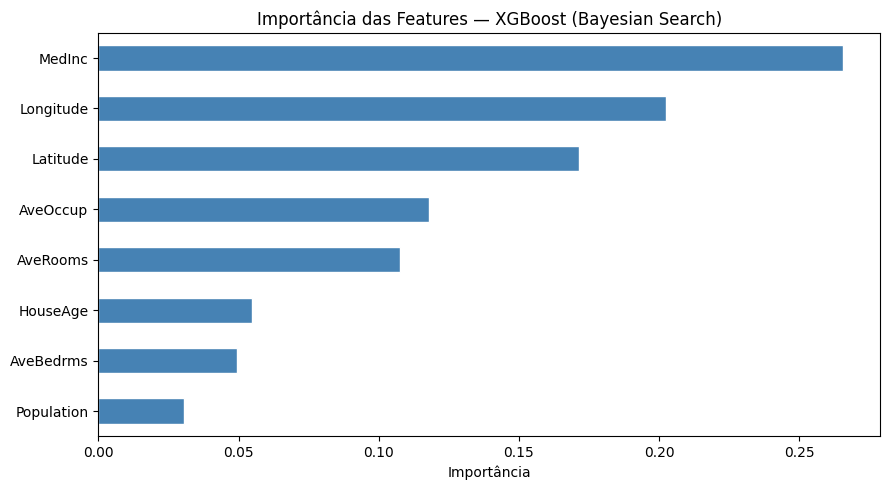

In [ ]:
# Importância das features — XGBoost (melhor modelo)
# Identifica qual modelo teve menor RMSE entre os otimizados
modelos_otimizados = {
    'XGBoost — Bayesian Search': bayes_search.best_estimator_,
    'XGBoost — Randomized Search': random_search.best_estimator_,
    'XGBoost — Grid Search': grid_search.best_estimator_
}

# Usar o melhor estimador para importância das features
feat_importance = pd.Series(
    bayes_search.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importância das Features — XGBoost (Bayesian Search)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

### Interpretação — Comparação Final e Importância das Features

**Resumo dos modelos com valores fixos (Regressão Linear, Random Forest, XGBoost baseline e otimizados):**

| Modelo | MAE | MSE | RMSE | R² |
|---|---|---|---|---|
| Regressão Linear | 0.5332 | 0.5559 | 0.7456 | 0.5758 |
| Random Forest | 0.3275 | 0.2554 | 0.5053 | 0.8051 |
| **XGBoost (baseline)** | 0.3096 | 0.2226 | 0.4718 | 0.8301 |
| XGBoost — Randomized Search | 0.2842 | 0.1946 | 0.4412 | 0.8515 |
| XGBoost — Bayesian Search | **0.2862** | **0.1943** | **0.4408** | **0.8517** |
| XGBoost — Grid Search | 0.2943 | 0.2044 | 0.4521 | 0.8440 |

*Ridge, Lasso, Extra Trees e Gradient Boosting: valores gerados dinamicamente na seção de comparação de algoritmos ao executar o notebook.*

**Evolução do desempenho ao longo do projeto:**
- Regressão Linear → XGBoost baseline: **-36.7% no RMSE** (0.7456 → 0.4718)
- XGBoost baseline → XGBoost Bayesian: **-6.6% adicional** (0.4718 → 0.4408)
- **Ganho total: -40.9% no RMSE** do início ao fim do projeto

**Ganho da otimização sobre o baseline XGBoost:**
- Bayesian Search: -6.6% no RMSE, -12.7% no MSE (+2.2pp no R²)
- Randomized Search: -6.5% no RMSE, -12.6% no MSE (+2.1pp no R²)
- Grid Search: -4.2% no RMSE, -8.2% no MSE (+1.4pp no R²)

**Importância das features (XGBoost otimizado):**

`MedInc` é a feature mais importante por ampla margem — confirma e quantifica a correlação de +0.688 observada na EDA. Em modelos de árvore, a importância é calculada pelo ganho acumulado nas divisões que usam aquela feature.

`Latitude` e `Longitude` juntas têm peso considerável, capturando a estrutura geográfica de valorização que o mapa da EDA evidenciou. O modelo aprende automaticamente "regiões caras" por meio de divisões combinadas nessas coordenadas.

`AveOccup` aparece com importância relevante apesar da correlação linear quase nula (-0.024) — demonstra que o XGBoost captura relações não-lineares que modelos lineares ignoram.

`HouseAge`, `AveBedrms` e `Population` têm menor contribuição relativa, mas contribuem para a precisão em casos extremos.

## Conclusão:

### O problema foi resolvido de forma satisfatória?

Sim. O melhor modelo (XGBoost + Bayesian Search) atingiu **R² = 0.8517** e **RMSE = 0.4408**, explicando 85% da variância dos preços com erro médio absoluto de USD ~28.6k — aceitável para dados imobiliários reais com alta heterogeneidade (imóveis de USD 15k a USD 500k+ no mesmo dataset).

### Principais achados na Análise Exploratória

- Dataset sem valores ausentes — 20.640 × 9 colunas completamente preenchidas
- **MedInc** é o preditor mais forte (**+0.688** de correlação com o alvo) e a feature de maior importância em todos os modelos
- A variável alvo tem **truncamento em 5.0** (USD 500k) — 1.071 registros (5.2%), prejudicando sistematicamente a predição de imóveis de alto padrão
- Localização geográfica é determinante: faixa costeira (SF, LA, San Diego) concentra os imóveis mais valiosos
- Outliers extremos em `AveOccup` (máx. 1.243 moradores/domicílio) e `AveRooms` (máx. 141 cômodos) — mantidos por robustez do XGBoost

### Quais modelos tiveram melhor desempenho?

| Grupo | Modelos | Faixa de R² |
|---|---|---|
| Lineares | Regressão Linear, Ridge, Lasso | 0.57–0.58 |
| Bagging | Extra Trees, Random Forest | 0.79–0.81 |
| Boosting | Gradient Boosting, XGBoost | 0.80–0.83 |

O **XGBoost** foi o melhor modelo baseline e o escolhido para otimização.

### A otimização melhorou os resultados?

Sim, em todos os métodos:

| Método | MAE | MSE | RMSE | R² | Tempo |
|---|---|---|---|---|---|
| XGBoost baseline | 0.3096 | 0.2226 | 0.4718 | 0.8301 | 1.2s |
| Randomized Search | **0.2842** | 0.1946 | 0.4412 | 0.8515 | 5min 36s |
| Bayesian Search | 0.2862 | **0.1943** | **0.4408** | **0.8517** | 6min 35s |
| Grid Search | 0.2943 | 0.2044 | 0.4521 | 0.8440 | **1min 21s** |

### Quais limitações foram observadas?

- **Truncamento em 5.0:** o modelo não prevê imóveis acima de USD 500k — subestima sistematicamente imóveis de alto padrão
- **Outliers extremos:** `AveOccup` e `AveRooms` com valores impossíveis em contexto residencial (prováveis erros de coleta)
- **Grade limitada no Grid Search:** não incluiu `learning_rate` próximo ao valor ótimo (~0.04), resultando em configuração subótima
- **Dados desatualizados:** censo de 1990 não reflete o mercado imobiliário atual da Califórnia

### O que poderia ser melhorado em uma próxima versão?

- **Engenharia de features:** criar `razao_quartos_comodos` (AveBedrms/AveRooms), distância ao litoral, distância aos centros urbanos (SF, LA) ou clusters geográficos poderiam capturar padrões que as coordenadas brutas não capturam isoladamente
- **Tratar o truncamento:** modelar o problema em duas etapas — classificador para identificar imóveis no teto (MedHouseVal = 5.0) + regressor para os demais — evitaria o viés de subestimação nos imóveis de alto valor
- **Mais algoritmos:** testar LightGBM e CatBoost, que têm desempenho competitivo com XGBoost em datasets tabulares e suportam features categóricas nativamente
- **Grid Search com grade expandida:** incluir `learning_rate` entre 0.01 e 0.05 para explorar a região ótima identificada pelos outros métodos
- **Dados mais recentes:** retreinar com dados imobiliários atuais (ex: Zillow, Redfin) para aplicação prática real